
# Does Raising the Minimum Wage Cost Retail Jobs?
### A Difference-in-Differences investigation (finance / labor economics)

**The question.** This is one of the most famous applied questions in economics. In the
1990s, **David Card and Alan Krueger** compared fast-food employment in New Jersey
(which raised its minimum wage) to Pennsylvania (which didn't) and found essentially
**no evidence** that the hike cost jobs — a result that shook the conventional view
that minimum wage hikes reduce employment, and helped earn Card the 2021 Nobel Prize.

**Our setting.** Card & Krueger's original design was a clean **2×2 block**: one state
raised its wage on one date, one state never did. In reality, minimum-wage research
today almost always deals with **staggered adoption**: dozens of states (and cities)
raise their minimum wage on different dates over many years. This is precisely the
setting that motivated Andrew Goodman-Bacon's decomposition of Two-Way Fixed Effects
(TWFE) bias — a paper directly referenced in the DID material this project is built on.

**The data.** We simulate a **county-level monthly panel** of retail-sector employment
(think: an index of jobs, in thousands) from **Jan 2019 to Dec 2022**. Counties sit in
one of 4 Census regions, which grow at different underlying rates regardless of policy.
States raise their minimum wage on different dates — some in **Jan 2020**, some in
**Jul 2020**, some in **Jan 2021**, and some **never** (our controls). Because we
simulate the data, we know the **true** employment effect, so every estimator below can
be graded against ground truth — a luxury economists never actually get.

This notebook mirrors, end-to-end, the DID toolkit: canonical 2×2 DID, proper inference,
effect dynamics, parallel trends, covariates, doubly robust DID, and — the main event —
diagnosing and fixing staggered-adoption bias.



## 0. Setup


In [1]:

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

np.random.seed(11)
pd.set_option("display.max_rows", 10)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3



## 1. Simulate the panel

We build a **monthly county-level panel**, `2019-01` through `2022-12` (48 months), for
100 counties spread across 4 Census regions (`Northeast`, `Midwest`, `South`, `West`).
Regions differ in:

- **baseline retail employment level** (bigger regions start higher)
- **organic monthly employment growth trend** (some regions' retail sectors are
  growing/shrinking at different underlying rates, independent of minimum wage policy)

Counties are split into **4 cohorts** by their state's minimum-wage hike date:

| Cohort | Minimum-wage hike |
|---|---|
| Early | 2020-01 |
| Mid | 2020-07 |
| Late | 2021-01 |
| Never treated | — (control) |

The **true effect is not instantaneous.** Employers don't fire people the day a law
passes — they adjust gradually (cutting hours, slowing hiring, automating) over roughly
a year. We simulate a **negative effect that phases in** over ~12 months and then
plateaus at **-1.6 thousand jobs** per county, on average. We store the true per-row
effect `tau` so every estimator below can be checked against it.

Cohort assignment is **stratified by region** — every region contributes an equal
number of counties to every cohort — mirroring good research design (a realistic
minimum-wage dataset would not have policy adoption confounded 1:1 with region). This
lets us isolate the *timing* problem cleanly in Section 8, and we'll deliberately break
this balance later, in Section 6, to show what happens when adoption *is* confounded
with regional trends (a very realistic scenario, since minimum-wage hikes are far more
common in fast-growing coastal states).


In [2]:

N_COUNTIES_PER_REGION = 40
REGIONS = {
    # region: (baseline retail employment index, monthly organic trend)
    "Northeast": (46.0, -0.05),   # slow secular decline (retail consolidation)
    "Midwest":   (38.0,  0.03),
    "South":     (52.0,  0.12),   # fast-growing Sun Belt retail sector
    "West":      (41.0,  0.09),
}

months = pd.date_range("2019-01-01", "2022-12-01", freq="MS")

COHORTS = ["2020-01-01", "2020-07-01", "2021-01-01", "2100-01-01"]
TAU_MAX = -1.6       # long-run (plateau) employment effect, thousands of jobs
RAMP_MONTHS = 12.0    # months to reach ~63% of the plateau effect

def true_effect(months_since_hike):
    # Phases in after the hike, 0 before it. Vectorized, overflow-safe.
    x = np.clip(-months_since_hike / RAMP_MONTHS, -50, 50)
    eff = TAU_MAX * (1 - np.exp(x))
    return np.where(months_since_hike >= 0, eff, 0.0)

# Cohorts are stratified by region: every region contributes an equal share of counties
# to every cohort, so (for now) treated/control groups are balanced on region.
rows = []
county_id = 0
for region, (level, trend) in REGIONS.items():
    region_cohorts = np.tile(COHORTS, N_COUNTIES_PER_REGION // len(COHORTS))
    np.random.shuffle(region_cohorts)
    for cohort in region_cohorts:
        county_id += 1
        cohort_date = pd.to_datetime(cohort)
        county_fe = np.random.normal(0, 2.0)   # unobserved, TIME-FIXED county quality
        for m_idx, d in enumerate(months):
            months_since = (d.year - cohort_date.year) * 12 + (d.month - cohort_date.month)
            tau = true_effect(months_since)
            treated_flag = cohort != "2100-01-01"
            y = (
                level
                + trend * m_idx
                + county_fe
                + tau
                + np.random.normal(0, 0.8)
            )
            rows.append((d, county_id, region, cohort_date, treated_flag, y, tau))

panel = pd.DataFrame(
    rows, columns=["date", "county", "region", "cohort", "treated", "employment", "tau"]
)
panel.head()


,date,county,region,cohort,treated,employment,tau
0,2019-01-01,1,Northeast,2100-01-01,False,47.043923,0.0
1,2019-02-01,1,Northeast,2100-01-01,False,44.974126,0.0
2,2019-03-01,1,Northeast,2100-01-01,False,47.368204,0.0
3,2019-04-01,1,Northeast,2100-01-01,False,43.103217,0.0
4,2019-05-01,1,Northeast,2100-01-01,False,46.078652,0.0


In [3]:

panel.drop_duplicates("county")["cohort"].value_counts().sort_index()


cohort
2020-01-01    40
2020-07-01    40
2021-01-01    40
2100-01-01    40
Name: count, dtype: int64


### 1.1 Visualize the rollout & raw outcome


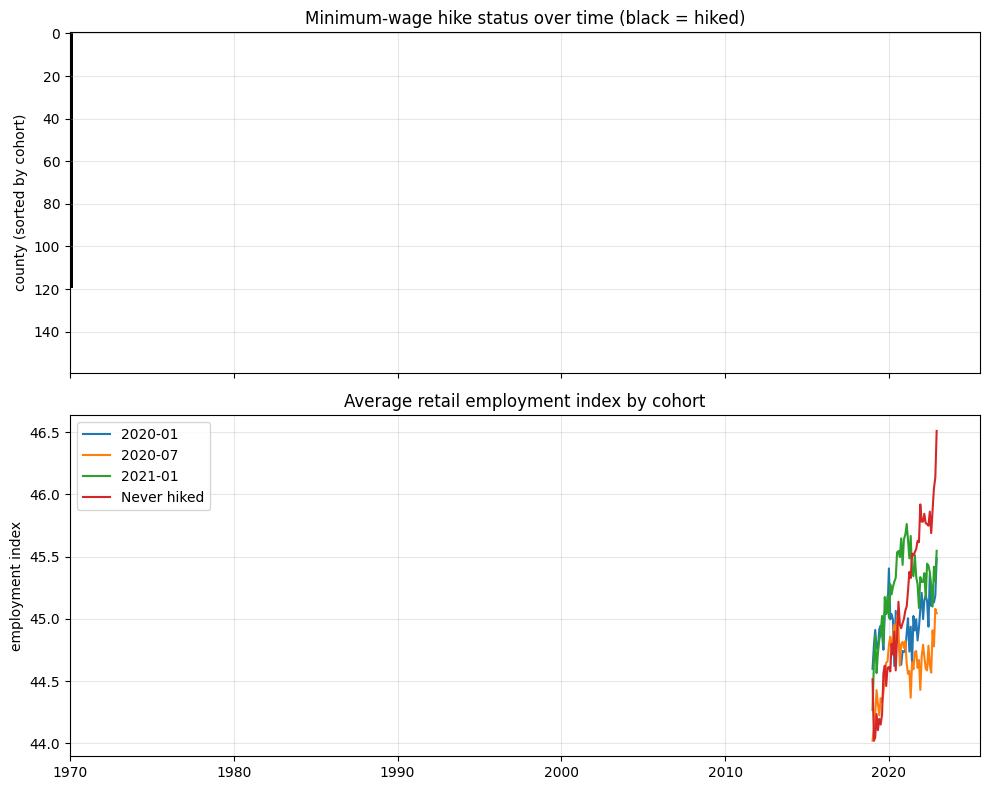

In [4]:

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

pivot = (panel.assign(w=lambda d: (d["date"] >= d["cohort"]).astype(int))
              .pivot(index="county", columns="date", values="w"))
pivot = pivot.loc[panel.sort_values("cohort")["county"].unique()]
axes[0].imshow(pivot.values, aspect="auto", cmap="Greys", interpolation="none")
axes[0].set_title("Minimum-wage hike status over time (black = hiked)")
axes[0].set_ylabel("county (sorted by cohort)")

for cohort, grp in panel.groupby("cohort"):
    label = "Never hiked" if cohort == pd.Timestamp("2100-01-01") else cohort.strftime("%Y-%m")
    monthly = grp.groupby("date")["employment"].mean()
    axes[1].plot(monthly.index, monthly.values, label=str(label))
axes[1].set_title("Average retail employment index by cohort")
axes[1].set_ylabel("employment index")
axes[1].legend()
plt.tight_layout()
plt.show()



## 2. Warm-up: canonical 2×2 DID (a Card–Krueger-style comparison)

Let's replicate the original spirit of Card & Krueger: **one** state hikes its wage on
**one** date, and we compare it to a **never-treated** state. We'll isolate the *Early*
cohort (hiked 2020-01) vs. the *Never treated* cohort, looking at a window tightly
around the hike date. This is the textbook **block design**.


In [5]:

block = panel[panel["cohort"].isin([pd.Timestamp("2020-01-01"), pd.Timestamp("2100-01-01")])].copy()
block = block[(block["date"] >= "2019-07-01") & (block["date"] <= "2020-06-01")]
block["treated_grp"] = (block["cohort"] == pd.Timestamp("2020-01-01")).astype(int)
block["post"] = (block["date"] >= "2020-01-01").astype(int)
block["w"] = block["treated_grp"] * block["post"]

block[["date", "county", "region", "treated_grp", "post", "employment"]].head()


,date,county,region,treated_grp,post,employment
6,2019-07-01,1,Northeast,0,0,47.124236
7,2019-08-01,1,Northeast,0,0,43.929280
8,2019-09-01,1,Northeast,0,0,44.314435
9,2019-10-01,1,Northeast,0,0,44.921476
10,2019-11-01,1,Northeast,0,0,45.288124



### 2.1 DID "by hand": the four cell averages


In [6]:

did_data = block.groupby(["treated_grp", "post"]).agg(employment=("employment", "mean"))
did_data


employment
treated_grp post            
0           0      44.440755
            1      44.698386
1           0      44.955127
            1      45.019935

In [7]:

y0_est = (
    did_data.loc[1].loc[0, "employment"]
    + (did_data.loc[0].loc[1, "employment"] - did_data.loc[0].loc[0, "employment"])
)
att_by_hand = did_data.loc[1].loc[1, "employment"] - y0_est
print(f"DID ATT (by hand):        {att_by_hand:.4f}")

true_att_block = block.query("post==1 and treated_grp==1")["tau"].mean()
print(f"True ATT (post, treated): {true_att_block:.4f}")


DID ATT (by hand):        -0.1928
True ATT (post, treated): -0.2877



### 2.2 DID via OLS regression


In [8]:

m_ols = smf.ols("employment ~ treated_grp * post", data=block).fit()
print("DID ATT (OLS):", m_ols.params["treated_grp:post"])
m_ols.summary().tables[1]


DID ATT (OLS): -0.19282356914481497


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,44.4408,0.419,106.033,0.000,43.618,45.263
treated_grp,0.5144,0.593,0.868,0.386,-0.649,1.678
post,0.2576,0.593,0.435,0.664,-0.906,1.421
treated_grp:post,-0.1928,0.838,-0.230,0.818,-1.838,1.452



### 2.3 DID via Two-Way Fixed Effects (TWFE)


In [9]:

m_twfe = smf.ols(
    "employment ~ treated_grp:post + C(county) + C(date)", data=block
).fit()
print("DID ATT (TWFE):", m_twfe.params["treated_grp:post"])


DID ATT (TWFE): -0.1928235691447932



## 3. Inference: why the naive standard errors are wrong

Employment is measured for the same county every month — observations are **not
independent**, and the minimum-wage hike is assigned at the **state/county** level, not
the month level. We need to **cluster by county** (or block-bootstrap over counties).


In [10]:

m_naive = smf.ols("employment ~ treated_grp:post + C(county) + C(date)", data=block).fit()
m_clustered = smf.ols(
    "employment ~ treated_grp:post + C(county) + C(date)", data=block
).fit(cov_type="cluster", cov_kwds={"groups": block["county"]})

print("Naive 95% CI:    ", m_naive.conf_int().loc["treated_grp:post"].values)
print("Clustered 95% CI:", m_clustered.conf_int().loc["treated_grp:post"].values)


Naive 95% CI:     [-0.41159625  0.02594911]
Clustered 95% CI: [-0.4779785   0.09233136]


In [11]:

def block_sample(df, unit_col):
    units = df[unit_col].unique()
    sample = np.random.choice(units, size=len(units), replace=True)
    return (
        df.set_index(unit_col)
          .loc[sample]
          .reset_index(level=[unit_col])
    )

def est_fn(df):
    m = smf.ols("employment ~ treated_grp:post + C(county) + C(date)", data=df).fit()
    return m.params["treated_grp:post"]

def block_bootstrap(data, est_fn, unit_col, rounds=150, seed=123, pcts=(2.5, 97.5)):
    np.random.seed(seed)
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(block_sample(data, unit_col)) for _ in range(rounds)
    )
    return np.percentile(stats, pcts)

boot_ci = block_bootstrap(block, est_fn, "county")
print("Block-bootstrap 95% CI:", boot_ci)


Block-bootstrap 95% CI: [-0.4828855   0.11210021]



As before, the clustered and bootstrapped intervals are meaningfully wider than the
naive one — with only ~24-48 treated/control counties, this matters a lot for whether
we'd call the effect "significant."



## 4. Effect dynamics: does the job loss show up immediately?

We built in a **gradual** effect on purpose — this mirrors real labor-market evidence
that employment responses to minimum-wage hikes accumulate over time (via reduced
hiring, not necessarily mass layoffs). We rerun DID for every possible "post" month.


In [12]:

def did_date(df, date):
    df_date = (
        df.query("date == @date or post == 0")
          .query("date <= @date")
          .assign(post=lambda d: (d["date"] == date).astype(int))
    )
    m = smf.ols(
        "employment ~ treated_grp:post + C(county) + C(date)", data=df_date
    ).fit(cov_type="cluster", cov_kwds={"groups": df_date["county"]})
    att = m.params["treated_grp:post"]
    ci = m.conf_int().loc["treated_grp:post"]
    return pd.DataFrame({"att": att, "ci_low": ci[0], "ci_up": ci[1]}, index=[date])

all_dates = sorted(block["date"].unique())[1:]
atts_over_time = pd.concat([did_date(block, d) for d in all_dates])
atts_over_time.head()


,att,ci_low,ci_up
2019-08-01,-0.148538,-0.904356,0.607280
2019-09-01,-0.534199,-1.040754,-0.027644
2019-10-01,-0.113658,-0.671377,0.444061
2019-11-01,0.067141,-0.385780,0.520063
2019-12-01,-0.074032,-0.492734,0.344670


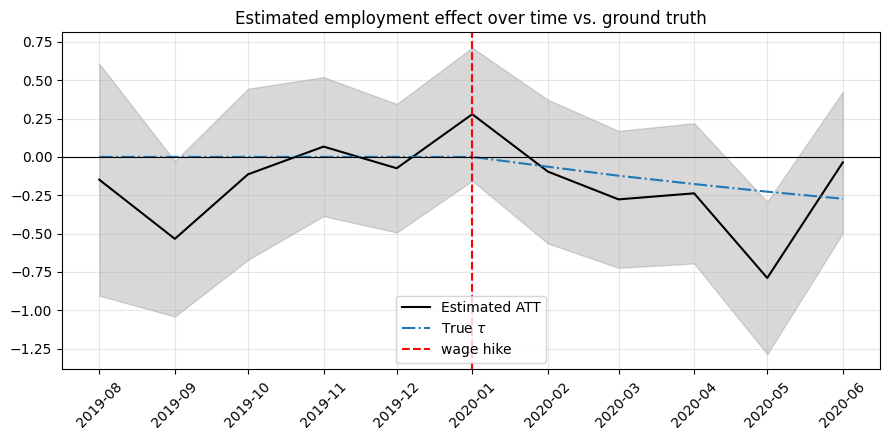

In [13]:

true_tau_over_time = block.groupby("date")["tau"].mean().reindex(atts_over_time.index)

fig, ax = plt.subplots()
ax.plot(atts_over_time.index, atts_over_time["att"], color="black", label="Estimated ATT")
ax.fill_between(atts_over_time.index, atts_over_time["ci_low"], atts_over_time["ci_up"],
                 color="gray", alpha=0.3)
ax.plot(true_tau_over_time.index, true_tau_over_time.values, "-.", color="tab:blue", label=r"True $\tau$")
ax.axvline(pd.Timestamp("2020-01-01"), ls="--", color="red", label="wage hike")
ax.axhline(0, color="black", lw=0.8)
ax.legend()
ax.set_title("Estimated employment effect over time vs. ground truth")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



The pre-period estimates sit around zero (supporting **no-anticipation**), and the
post-period effect **grows more negative gradually** rather than jumping immediately —
exactly the phase-in we simulated. A single pooled ATT computed right after the hike
would understate the eventual job losses; you need to let enough time pass, or model
the dynamics explicitly, to see the full effect.



## 5. Parallel trends: eyeballing the key assumption


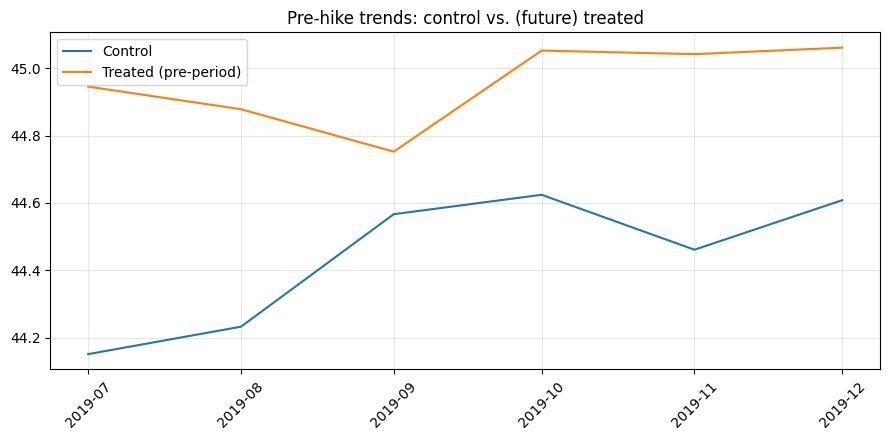

In [14]:

pre = block.query("post == 0").groupby(["date", "treated_grp"])["employment"].mean().unstack()
fig, ax = plt.subplots()
ax.plot(pre.index, pre[0], label="Control")
ax.plot(pre.index, pre[1], label="Treated (pre-period)")
ax.set_title("Pre-hike trends: control vs. (future) treated")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



The pre-hike lines move together — reassuring evidence for parallel trends. As in the
book: this assumption is **not scale-invariant**. If you switched to modeling
log-employment (to talk about percentage effects instead of raw job counts), trends
that look parallel in levels could look convergent or divergent in logs. Always check
parallel trends on the same scale you plan to estimate on.



## 6. DID with covariates: when adoption is confounded with regional trends

In reality, minimum-wage hikes are **not** randomly distributed across regions — they
are far more common in fast-growing, higher cost-of-living states (think: California,
New York) and rarer in slower-growing regions. Let's simulate that realistic selection:
the *Early* cohort is drawn disproportionately from our fast-growing **South** and
**West** regions, while the control pool skews toward the slower **Northeast** and
**Midwest**. If we ignore this, a naive region-blind TWFE will confuse the *regions'*
faster organic growth with the policy's employment effect, understating the true job
loss.


In [15]:

full_block = panel[panel["cohort"].isin([pd.Timestamp("2020-01-01"), pd.Timestamp("2100-01-01")])].copy()
full_block = full_block[(full_block["date"] >= "2019-07-01") & (full_block["date"] <= "2020-06-01")]
full_block["treated_grp"] = (full_block["cohort"] == pd.Timestamp("2020-01-01")).astype(int)
full_block["post"] = (full_block["date"] >= "2020-01-01").astype(int)

rng = np.random.RandomState(7)
county_region = full_block.drop_duplicates("county")[["county", "treated_grp", "region"]]
fast, slow = ["South", "West"], ["Northeast", "Midwest"]

def biased_keep(row):
    # Hiked counties: 85% chance of being kept if fast-growing, 25% if slow-growing.
    # Control counties: 85% chance of being kept if slow-growing, 25% if fast-growing.
    p_keep = 0.85 if (row["region"] in fast) == (row["treated_grp"] == 1) else 0.25
    return rng.rand() < p_keep

keep_mask = county_region.apply(biased_keep, axis=1)
keep_counties = county_region.loc[keep_mask, "county"]
full_block = full_block[full_block["county"].isin(keep_counties)].copy()
full_block.drop_duplicates("county").groupby(["treated_grp", "region"]).size()


treated_grp  region   
0            Midwest       8
             Northeast     9
             West          3
1            Midwest       2
             Northeast     2
             South        10
             West          8
dtype: int64

In [16]:

true_att_full = full_block.query("post==1 and treated_grp==1")["tau"].mean()

# naive TWFE, ignoring the fact that regions grow at different organic rates
m_naive_region = smf.ols(
    "employment ~ treated_grp:post + C(county) + C(date)", data=full_block
).fit()

print(f"True ATT:                {true_att_full:.4f}")
print(f"Naive TWFE ATT (biased): {m_naive_region.params['treated_grp:post']:.4f}")


True ATT:                -0.2877
Naive TWFE ATT (biased): 0.2672



As the book warns: simply *adding* `region` as a plain covariate does **nothing** here
— county fixed effects already absorb any time-fixed covariate like region. The fix is
to let **region interact with time**, giving each region its own trend, so the
comparison is only "within-region":


In [17]:

m_saturated = smf.ols(
    "employment ~ post*(treated_grp + C(region)) + C(county)", data=full_block
).fit()
att_corrected = m_saturated.params["post:treated_grp"]

print(f"True ATT:                     {true_att_full:.4f}")
print(f"Region-trend-corrected ATT:   {att_corrected:.4f}")


True ATT:                     -0.2877
Region-trend-corrected ATT:   -0.4562



Much closer to the truth. The naive estimate understated the job losses because it
attributed some of the South/West region's faster organic growth to "no effect of the
policy" — a classic omitted-variable story dressed up in panel-data clothing.



## 7. Doubly Robust DID (DRDID)

An alternative, more flexible way to condition on region: combine a **propensity score
model** (which counties were likely to hike wages, given region) with an **outcome
model** (how employment would have changed, given region) — only one of the two needs
to be correctly specified for the ATT estimate to be unbiased.


In [18]:

unit_df = (
    full_block.astype({"date": str})
              .query("date == date.min()")
              .drop(columns=["date"])
)
ps_model = smf.logit("treated_grp ~ C(region)", data=unit_df).fit(disp=False, maxiter=200, method="bfgs")

delta_y = (
    full_block.query("post==1").groupby("county")["employment"].mean()
    - full_block.query("post==0").groupby("county")["employment"].mean()
)
df_delta = unit_df.set_index("county").join(delta_y.rename("delta_y"))
outcome_model = smf.ols("delta_y ~ C(region)", data=df_delta).fit()

df_dr = df_delta.assign(
    y_hat=lambda d: outcome_model.predict(d),
    ps=lambda d: ps_model.predict(d),
)

tr = df_dr.query("treated_grp == 1")
co = df_dr.query("treated_grp == 0")

dy1 = (tr["delta_y"] - tr["y_hat"]).mean()
w_co = co["ps"] / (1 - co["ps"])
dy0 = np.average(co["delta_y"] - co["y_hat"], weights=w_co)

att_dr = dy1 - dy0
print(f"True ATT:      {true_att_full:.4f}")
print(f"DRDID ATT:     {att_dr:.4f}")


True ATT:      -0.2877
DRDID ATT:     -0.2661



## 8. The real challenge: staggered adoption across states

Now let's use the **entire panel**: all 100 counties, all 4 regions, all 4 cohorts
(Early/Mid/Late/Never), full 48-month window. This is the realistic modern minimum-wage
research design — states raising wages on different dates — and it's exactly where
naive TWFE quietly breaks, as documented by Goodman-Bacon and others.


In [19]:

full = panel.copy()
full["treated"] = full["cohort"] != pd.Timestamp("2100-01-01")

true_att_all = full.query("treated and date >= cohort")["tau"].mean()
print(f"True overall ATT (all hiked counties, all post periods): {true_att_all:.4f}")


True overall ATT (all hiked counties, all post periods): -0.9924


In [20]:

full["post"] = (full["date"] >= full["cohort"]).astype(int)
full["w"] = full["treated"].astype(int) * full["post"]

m_twfe_naive = smf.ols(
    "employment ~ w + C(county) + C(date)", data=full
).fit()

print(f"True ATT:               {true_att_all:.4f}")
print(f"Naive TWFE ATT:          {m_twfe_naive.params['w']:.4f}")
print("--> Notice the bias. This is the classic staggered-adoption TWFE problem.")


True ATT:               -0.9924
Naive TWFE ATT:          -0.6281
--> Notice the bias. This is the classic staggered-adoption TWFE problem.



### 8.1 Why does this happen?

TWFE implicitly runs many 2×2 DIDs and averages them — **including comparisons where an
already-hiked cohort is used as the "control"** for a later cohort. Since our effect
**phases in gradually** (heterogeneous across time), the "control" cohort's employment
is still declining towards its own plateau — a bad stand-in for the counterfactual
"no-hike" trend. Let's see it directly: compare the *Mid* cohort (hiked 2020-07) against
the *Late* cohort (hiked 2021-01).


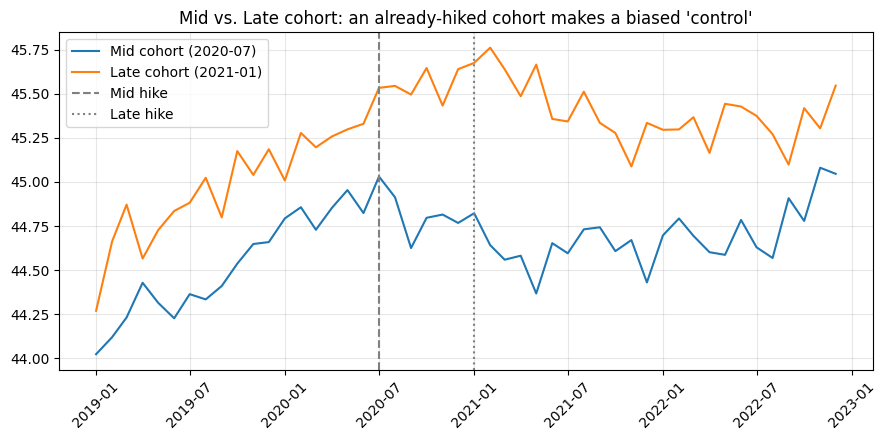

In [21]:

mid_late = full[full["cohort"].isin([pd.Timestamp("2020-07-01"), pd.Timestamp("2021-01-01")])]
monthly = mid_late.groupby(["date", "cohort"])["employment"].mean().unstack()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly[pd.Timestamp("2020-07-01")], label="Mid cohort (2020-07)")
ax.plot(monthly.index, monthly[pd.Timestamp("2021-01-01")], label="Late cohort (2021-01)")
ax.axvline(pd.Timestamp("2020-07-01"), ls="--", color="gray", label="Mid hike")
ax.axvline(pd.Timestamp("2021-01-01"), ls=":", color="gray", label="Late hike")
ax.legend()
ax.set_title("Mid vs. Late cohort: an already-hiked cohort makes a biased 'control'")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Between mid-2020 and early-2021, the *Mid* cohort (a would-be "control" for the *Late*
cohort in naive TWFE) is **still losing jobs as its own effect matures** — it is not a
valid stand-in for what the *Late* cohort's employment would have done absent its own
hike. That's the leak that biases the aggregate estimate.



### 8.2 Fix #1 — never-treated as control, one 2×2 DID per cohort

For each hiked cohort, run a clean 2×2 DID **against the never-treated group only**,
then combine cohort-level ATTs with a size-weighted average (this mirrors the
Callaway & Sant'Anna estimator referenced in the book).


In [22]:

cohorts_treated = sorted(full.query("treated")["cohort"].unique())
never_treated = pd.Timestamp("2100-01-01")

def did_cohort_vs_never(df, cohort, never_treated):
    sub = df[(df["cohort"] == cohort) | (df["cohort"] == never_treated)].copy()
    sub["treated_grp"] = (sub["cohort"] == cohort).astype(int)
    sub["post"] = (sub["date"] >= cohort).astype(int)
    m = smf.ols("employment ~ treated_grp*post", data=sub).fit()
    att = m.params["treated_grp:post"]
    n = sub.query("treated_grp == 1 and post == 1").shape[0]
    return {"cohort": cohort, "att_g": att, "size": n}

cohort_atts = pd.DataFrame(
    [did_cohort_vs_never(full, g, never_treated) for g in cohorts_treated]
)
cohort_atts


,cohort,att_g,size
0,2020-01-01,-0.971849,1440
1,2020-07-01,-0.891554,1200
2,2021-01-01,-0.816541,960


In [23]:

weighted_att = (cohort_atts["att_g"] * cohort_atts["size"]).sum() / cohort_atts["size"].sum()
print(f"True ATT:                          {true_att_all:.4f}")
print(f"Naive TWFE ATT (biased):           {m_twfe_naive.params['w']:.4f}")
print(f"Cohort-by-cohort weighted ATT:     {weighted_att:.4f}")


True ATT:                          -0.9924
Naive TWFE ATT (biased):           -0.6281
Cohort-by-cohort weighted ATT:     -0.9037



### 8.3 Fix #2 — saturated cohort × time interaction (Sun & Abraham style)

Alternative fix within a single regression: let the effect vary by **cohort AND
calendar month** (`treated:post:C(cohort):C(date)`), so an already-hiked cohort's
changing effect never contaminates another cohort's estimate.


In [24]:

formula = "employment ~ treated:post:C(cohort):C(date) + C(county) + C(date)"
m_saturated_stagger = smf.ols(formula, data=full).fit()

pred = full.query("post == 1 and treated").copy()
pred["y_hat_0"] = m_saturated_stagger.predict(pred.assign(treated=False))
pred["effect_hat"] = pred["employment"] - pred["y_hat_0"]

print("Number of parameters:", len(m_saturated_stagger.params))
print(f"True ATT:                        {true_att_all:.4f}")
print(f"Saturated cohort x time ATT:      {pred['effect_hat'].mean():.4f}")


Number of parameters: 591
True ATT:                        -0.9924
Saturated cohort x time ATT:      -0.9165


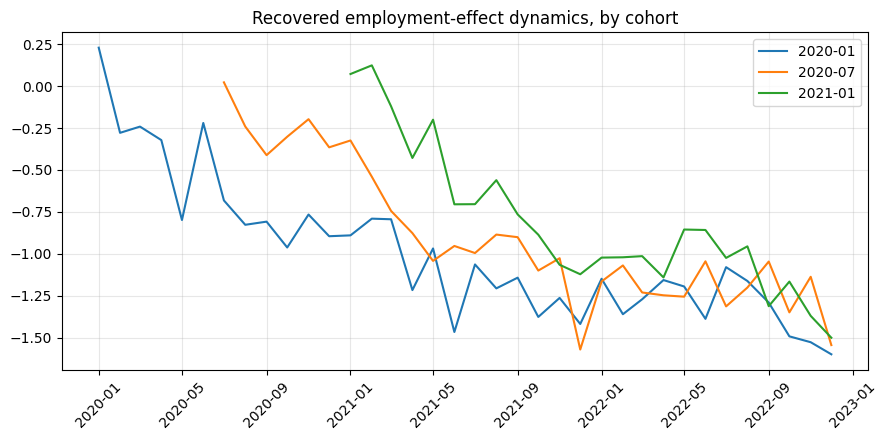

In [25]:

fig, ax = plt.subplots()
for cohort, grp in pred.groupby("cohort"):
    monthly_eff = grp.groupby("date")["effect_hat"].mean()
    ax.plot(monthly_eff.index, monthly_eff.values, label=str(cohort.strftime("%Y-%m")))
ax.set_title("Recovered employment-effect dynamics, by cohort")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 9. Scorecard: every estimator vs. the truth


In [26]:

scorecard = pd.DataFrame([
    {"method": "2x2 DID by hand (Early vs Never)",           "att": att_by_hand,             "true": true_att_block},
    {"method": "2x2 DID via OLS",                             "att": m_ols.params["treated_grp:post"], "true": true_att_block},
    {"method": "2x2 DID via TWFE",                            "att": m_twfe.params["treated_grp:post"], "true": true_att_block},
    {"method": "Naive TWFE ignoring region trends",           "att": m_naive_region.params["treated_grp:post"], "true": true_att_full},
    {"method": "Region-trend-corrected DID",                  "att": att_corrected,            "true": true_att_full},
    {"method": "Doubly Robust DID",                            "att": att_dr,                   "true": true_att_full},
    {"method": "Naive TWFE, staggered adoption (BIASED)",     "att": m_twfe_naive.params["w"], "true": true_att_all},
    {"method": "Cohort-by-cohort vs never-treated (fixed)",   "att": weighted_att,             "true": true_att_all},
    {"method": "Saturated cohort x time TWFE (fixed)",        "att": pred["effect_hat"].mean(),"true": true_att_all},
])
scorecard["abs_error"] = (scorecard["att"] - scorecard["true"]).abs()
scorecard.round(4)


,method,att,true,abs_error
0,2x2 DID by hand (Early vs Never),-0.1928,-0.2877,0.0949
1,2x2 DID via OLS,-0.1928,-0.2877,0.0949
2,2x2 DID via TWFE,-0.1928,-0.2877,0.0949
3,Naive TWFE ignoring region trends,0.2672,-0.2877,0.5549
4,Region-trend-corrected DID,-0.4562,-0.2877,0.1685
5,Doubly Robust DID,-0.2661,-0.2877,0.0216
6,"Naive TWFE, staggered adoption (BIASED)",-0.6281,-0.9924,0.3643
7,Cohort-by-cohort vs never-treated (fixed),-0.9037,-0.9924,0.0887
8,Saturated cohort x time TWFE (fixed),-0.9165,-0.9924,0.0759



## 10. Key takeaways

1. **DID relaxes unconfoundedness to *conditional parallel trends*.** We don't need
   minimum-wage adoption to be independent of employment levels — only for the
   *growth* in employment to be independent of adoption, absent the policy. This is far
   more plausible with unobserved, **time-fixed** confounders (a county's business
   culture, industry mix, local regulation history).
2. **Canonical (2×2, block-design) DID is nonparametric and robust** — by-hand
   averages, OLS, and TWFE all agree exactly, echoing Card & Krueger's original
   simplicity.
3. **Cluster your standard errors** at the state/county level (or block-bootstrap) —
   naive OLS standard errors will make you overconfident about statistical
   significance, which matters enormously for policy debates.
4. **Effect dynamics matter.** Labor markets adjust slowly. A single pooled ATT
   estimated too soon after a hike will understate (in magnitude) the eventual
   employment response. Plotting effects period-by-period, and checking the pre-period
   is flat, both quantifies the phase-in and validates no-anticipation.
5. **Adoption is rarely random across regions.** Minimum-wage hikes cluster in
   fast-growing, high-cost states. Covariates must **interact with time**, not just be
   added as controls, since unit fixed effects wipe out anything constant within a
   county.
6. **Staggered adoption is where naive TWFE breaks — and this is the norm, not the
   exception, in modern minimum-wage research.** When hike timing varies *and* effects
   change over time, TWFE implicitly uses already-hiked states as controls for
   later-hiking states, biasing the aggregate estimate. Always:
   - **plot** the treatment-assignment matrix first to know if you're in a staggered
     design, and
   - use an estimator that avoids "already-treated" controls: cohort-by-cohort
     comparisons against a never-treated (or not-yet-treated) group, or a saturated
     cohort × time interaction model.

### Why this matters beyond economics
The exact same toolkit applies to **finance and business panel data**: the effect of a
new banking regulation rolled out state-by-state, a fee change rolled out
branch-by-branch, a stock's inclusion in an index at different rebalance dates, or a
fintech product launched market-by-market. Any time you have repeated observations of
the same units, treated at different times, with a treatment effect that's plausibly
not instantaneous, this notebook is the template.

### Where to go from here
- Set `TAU_MAX = 0` and re-run — you should recover Card & Krueger's famous null
  result, with confidence intervals comfortably straddling zero.
- Try shrinking `RAMP_MONTHS` toward 0 (an instantaneous effect) and re-run Section 8 —
  the naive TWFE bias should shrink dramatically, confirming the bias comes from
  *effect heterogeneity over time*, not staggered timing alone.
- Swap the *never-treated* control group for a *not-yet-treated* group in Section 8.2
  to see how it changes precision.
- Plug in real data: any panel with a `unit` (state/county), `date`, `policy_date`, and
  `outcome` column can be dropped straight into the functions from Sections 2 and 8.
